In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
import warnings
warnings.filterwarnings("ignore")
import matplotlib.ticker as mticker

In [2]:
df = pd.read_csv("Housing.csv") 
#you can download the dataset from Kaggle follo:
#  https://www.kaggle.com/datasets/yasserh/housing-prices-dataset
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Dataset shape: (545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
price                int64
area                 int64
bedrooms            

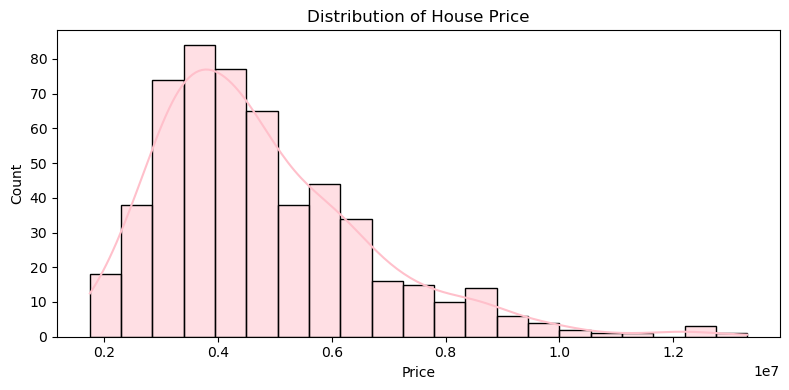

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(df["price"], kde=True, color="pink")
plt.title("Distribution of House Price")
plt.xlabel("Price")
plt.tight_layout()
plt.savefig("01_price_distribution.png", dpi=150)
plt.show()

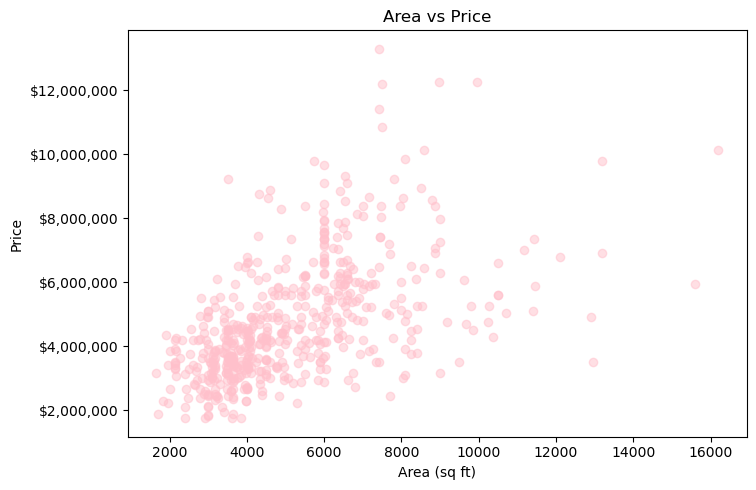

In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(df["area"], df["price"], alpha=0.5, color="pink")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.tight_layout()
plt.savefig("02_area_vs_price.png", dpi=150)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

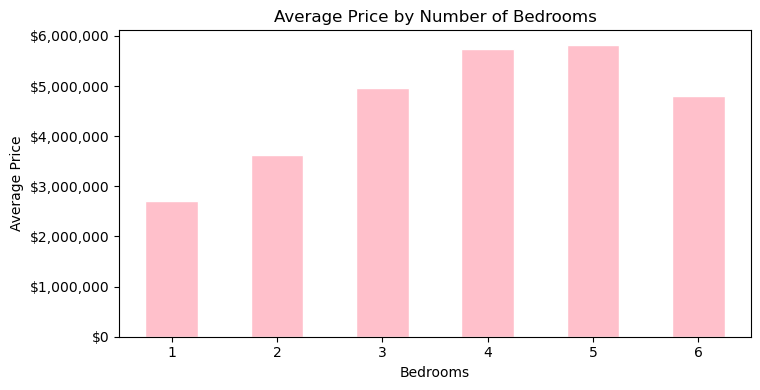

In [21]:
plt.figure(figsize=(7, 4))
df.groupby("bedrooms")["price"].mean().plot(kind="bar", color="pink", edgecolor="white")
plt.title("Average Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("03_price_by_bedrooms.png", dpi=150)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

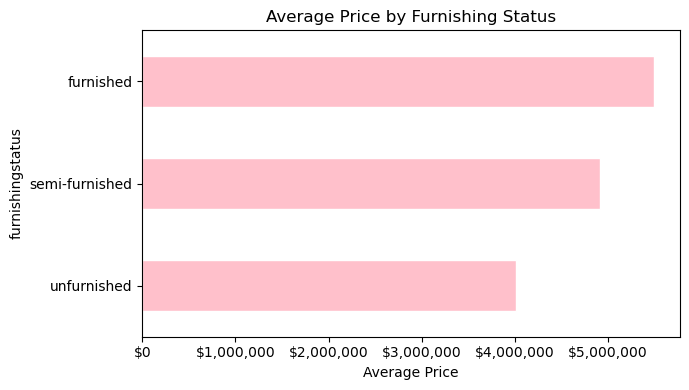

In [25]:
plt.figure(figsize=(7, 4))
df.groupby("furnishingstatus")["price"].mean().sort_values().plot(kind="barh", color="pink", edgecolor="white")
plt.title("Average Price by Furnishing Status")
plt.xlabel("Average Price")
plt.tight_layout()
plt.savefig("04_price_by_furnishing.png", dpi=150)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

In [26]:
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
df = pd.get_dummies(df, columns=binary_cols, drop_first=True)
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)
print("\nColumns after encoding:\n", df.columns.tolist())
print(df.head())


Columns after encoding:
 ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False       

In [27]:
X= df.drop(columns=["price"])
y= np.log1p(df["price"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler= StandardScaler()
X_train_sc= scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")


Train: (436, 13) | Test: (109, 13)


In [28]:
model= RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
preds= model.predict(X_test)
preds_actual= np.expm1(preds)
y_test_actual= np.expm1(y_test)

rmse= np.sqrt(mean_squared_error(y_test, preds))
mae= mean_absolute_error(y_test_actual, preds_actual)
r2= r2_score(y_test, preds)

print(f"RMSE: {rmse:.4f} | MAE: ${mae:,.0f} | R²: {r2:.4f}")

RMSE: 0.2668 | MAE: $1,019,485 | R²: 0.6315


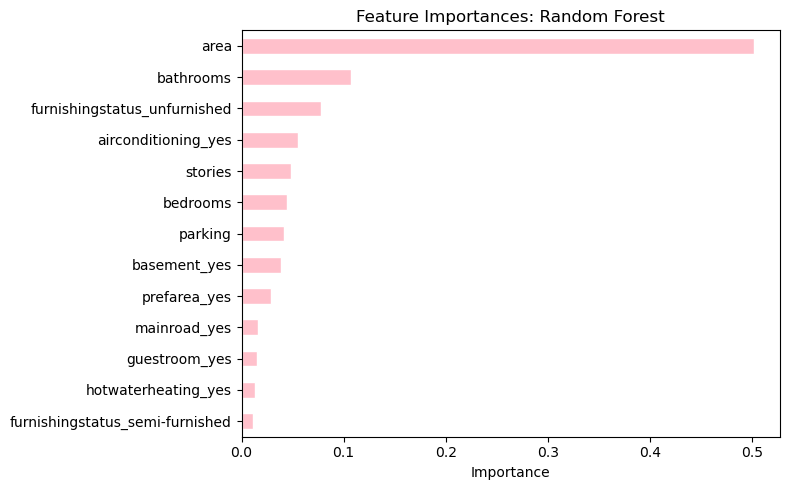

In [29]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
plt.figure(figsize=(8, 5))
feat_imp.sort_values().plot(kind="barh", color="pink", edgecolor="white")
plt.title("Feature Importances: Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

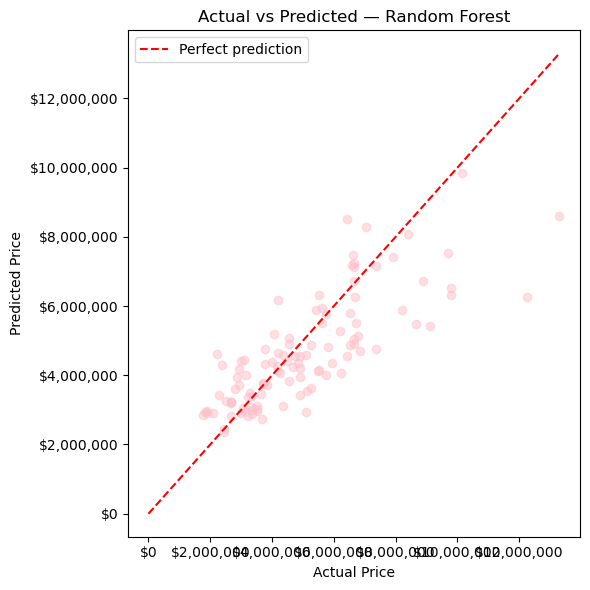

In [30]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_actual, preds_actual, alpha=0.5, color="pink")
max_val= max(y_test_actual.max(), preds_actual.max())
plt.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.title("Actual vs Predicted — Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()